# Notebook 08 — GAM: Weather Effects on Cycling Demand
Fit Generalized Additive Models to estimate nonlinear weather effects,
controlling for calendar patterns and site fixed effects.

## 0. Imports & Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pygam"])


0

In [2]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pygam import PoissonGAM, s, f, l
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

train = panel_good[panel_good["date"].dt.year == 2024].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

print(f"Train size : {len(train):,} rows (2024)")
print(f"Test size  : {len(test):,} rows (2025)")
print(f"Columns    : {list(panel_good.columns)}")

Train size : 48,229 rows (2024)
Test size  : 47,830 rows (2025)
Columns    : ['site ID', 'date', 'aantal', 'morning_peak_count', 'evening_peak_count', 'peak_ratio', 'year', 'month', 'dayofweek', 'is_weekend', 'season', 'low_coverage', 'lon', 'lat', 'naam', 'gemeente', 'wegnr', 'district', 'install_date', 'temp_avg', 'temp_max', 'temp_min', 'precip_total', 'wind_avg', 'wind_max', 'humidity_avg', 'sunshine_min', 'rain_hours', 'precip_morning', 'wind_morning', 'precip_evening', 'wind_evening', 'is_rainy_day', 'is_cold_day', 'is_windy_day', 'is_bad_weather', 'public_holiday_name', 'is_public_holiday', 'school_holiday_name', 'is_school_holiday', 'ku_leuven_period', 'ku_is_teaching', 'ku_is_exam', 'ku_is_exam_prep', 'ku_is_recess', 'is_any_holiday', 'is_regular_day', 'day_type', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'temp_avg_lag2', 'precip_total_lag2', 'wind_avg_lag2', 'commute_score', 'site_type']


## 1. Feature Engineering

In [3]:
le_site = LabelEncoder()
train["site_idx"] = le_site.fit_transform(train["site ID"])
test["site_idx"]  = le_site.transform(test["site ID"])

train["dow"]       = train["dayofweek"].astype(int)
test["dow"]        = test["dayofweek"].astype(int)
train["month_int"] = train["month"].astype(int)
test["month_int"]  = test["month"].astype(int)

for col in ["is_weekend", "is_public_holiday",
            "is_school_holiday", "is_bad_weather"]:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)

WEATHER_FEATURES  = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1",
]
CALENDAR_FEATURES = [
    "dow", "month_int",
    "is_weekend", "is_public_holiday", "is_school_holiday",
]
SITE_FEATURE  = ["site_idx"]
ALL_FEATURES  = WEATHER_FEATURES + CALENDAR_FEATURES + SITE_FEATURE

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Train shape: {train.shape}  |  Test shape: {test.shape}")

Features (13): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'dow', 'month_int', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'site_idx']
Train shape: (48229, 59)  |  Test shape: (47830, 59)


## 2. Prepare Feature Matrix

In [4]:
def make_X_y(df, features):
    cols = features + ["aantal"]
    df_clean = df[cols].dropna()
    X = df_clean[features].values
    y = df_clean["aantal"].values.astype(float)
    return X, y, df_clean.index

X_train, y_train, train_idx = make_X_y(train, ALL_FEATURES)
X_test,  y_test,  test_idx  = make_X_y(test,  ALL_FEATURES)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"y_train — mean: {y_train.mean():.1f}, std: {y_train.std():.1f}, "
      f"min: {y_train.min():.0f}, max: {y_train.max():.0f}")

X_train : (48098, 13)  |  y_train : (48098,)
X_test  : (47830, 13)   |  y_test  : (47830,)
y_train — mean: 500.2, std: 699.0, min: 0, max: 7281


## 3. Model A — Full GAM (all stations)
Feature index mapping:
- 0: temp_avg → s()  
- 1: precip_total → s()  
- 2: wind_avg → s()  
- 3: sunshine_min → s()  
- 4: humidity_avg → s()  
- 5: temp_avg_lag1 → s()  
- 6: precip_total_lag1 → s()  
- 7: dow → f()  
- 8: month_int → s()  
- 9: is_weekend → l()  
- 10: is_public_holiday → l()  
- 11: is_school_holiday → l()  
- 12: site_idx → f() (site fixed effect)

In [5]:
gam_full = PoissonGAM(
    s(0, n_splines=10) +  # temp_avg
    s(1, n_splines=8)  +  # precip_total
    s(2, n_splines=8)  +  # wind_avg
    s(3, n_splines=8)  +  # sunshine_min
    s(4, n_splines=8)  +  # humidity_avg
    s(5, n_splines=8)  +  # temp_avg_lag1
    s(6, n_splines=8)  +  # precip_total_lag1
    f(7)               +  # day of week
    s(8, n_splines=8)  +  # month
    l(9)               +  # is_weekend
    l(10)              +  # is_public_holiday
    l(11)              +  # is_school_holiday
    f(12),                # site fixed effect
    max_iter=100
)

print("Fitting full GAM... (may take 2-5 minutes)")
gam_full.fit(X_train, y_train)
print(f"GAM converged: {gam_full._is_fitted}")

y_pred_train = gam_full.predict(X_train)
y_pred_test  = gam_full.predict(X_test)

train_mae  = mean_absolute_error(y_train, y_pred_train)
test_mae   = mean_absolute_error(y_test,  y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_test    = 1 - np.sum((y_test - y_pred_test)**2) / \
                 np.sum((y_test - y_test.mean())**2)

print("\n" + "=" * 52)
print("MODEL A \u2014 Full GAM Performance")
print("=" * 52)
print(f"Train MAE  : {train_mae:.1f}  cyclists/day")
print(f"Test  MAE  : {test_mae:.1f}  cyclists/day")
print(f"Train RMSE : {train_rmse:.1f}")
print(f"Test  RMSE : {test_rmse:.1f}")
print(f"Test  R\u00b2   : {r2_test:.3f}")
print("=" * 52)

Fitting full GAM... (may take 2-5 minutes)
GAM converged: True

MODEL A — Full GAM Performance
Train MAE  : 105.9  cyclists/day
Test  MAE  : 125.8  cyclists/day
Train RMSE : 227.5
Test  RMSE : 261.0
Test  R²   : 0.878


## 4. Model B — Commuter GAM

In [6]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]  == "commuter"].copy()

le_c = LabelEncoder()
train_c["site_idx"] = le_c.fit_transform(train_c["site ID"])
test_c["site_idx"]  = le_c.transform(test_c["site ID"])

X_train_c, y_train_c, _ = make_X_y(train_c, ALL_FEATURES)
X_test_c,  y_test_c,  _ = make_X_y(test_c,  ALL_FEATURES)

gam_commuter = PoissonGAM(
    s(0, n_splines=10) + s(1, n_splines=8) + s(2, n_splines=8) +
    s(3, n_splines=8)  + s(4, n_splines=8) + s(5, n_splines=8) +
    s(6, n_splines=8)  + f(7) + s(8, n_splines=8) +
    l(9) + l(10) + l(11) + f(12),
    max_iter=100
)
print("Fitting commuter GAM...")
gam_commuter.fit(X_train_c, y_train_c)

y_pred_c = gam_commuter.predict(X_test_c)
mae_c    = mean_absolute_error(y_test_c, y_pred_c)
r2_c     = 1 - np.sum((y_test_c - y_pred_c)**2) / \
               np.sum((y_test_c - y_test_c.mean())**2)
print(f"Commuter GAM  \u2014  Test MAE: {mae_c:.1f}   R\u00b2: {r2_c:.3f}")

Fitting commuter GAM...
Commuter GAM  —  Test MAE: 81.0   R²: 0.899


## 5. Model C — Leisure GAM

In [7]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]  == "leisure"].copy()

le_l = LabelEncoder()
train_l["site_idx"] = le_l.fit_transform(train_l["site ID"])
test_l["site_idx"]  = le_l.transform(test_l["site ID"])

X_train_l, y_train_l, _ = make_X_y(train_l, ALL_FEATURES)
X_test_l,  y_test_l,  _ = make_X_y(test_l,  ALL_FEATURES)

gam_leisure = PoissonGAM(
    s(0, n_splines=10) + s(1, n_splines=8) + s(2, n_splines=8) +
    s(3, n_splines=8)  + s(4, n_splines=8) + s(5, n_splines=8) +
    s(6, n_splines=8)  + f(7) + s(8, n_splines=8) +
    l(9) + l(10) + l(11) + f(12),
    max_iter=100
)
print("Fitting leisure GAM...")
gam_leisure.fit(X_train_l, y_train_l)

y_pred_l = gam_leisure.predict(X_test_l)
mae_l    = mean_absolute_error(y_test_l, y_pred_l)
r2_l     = 1 - np.sum((y_test_l - y_pred_l)**2) / \
               np.sum((y_test_l - y_test_l.mean())**2)
print(f"Leisure GAM  \u2014  Test MAE: {mae_l:.1f}   R\u00b2: {r2_l:.3f}")

print("\n" + "=" * 52)
print("MODEL COMPARISON")
print("=" * 52)
print(f"{'Model':<15} | {'Test MAE':>9} | {'Test R\u00b2':>8}")
print("-" * 40)
print(f"{'Full (all)':<15} | {test_mae:>8.1f}  | {r2_test:>7.3f}")
print(f"{'Commuter only':<15} | {mae_c:>8.1f}  | {r2_c:>7.3f}")
print(f"{'Leisure only':<15} | {mae_l:>8.1f}  | {r2_l:>7.3f}")
print("=" * 52)

Fitting leisure GAM...
Leisure GAM  —  Test MAE: 145.5   R²: 0.670

MODEL COMPARISON
Model           |  Test MAE |  Test R²
----------------------------------------
Full (all)      |    125.8  |   0.878
Commuter only   |     81.0  |   0.899
Leisure only    |    145.5  |   0.670


## 6. Partial Dependence Plots — fig20

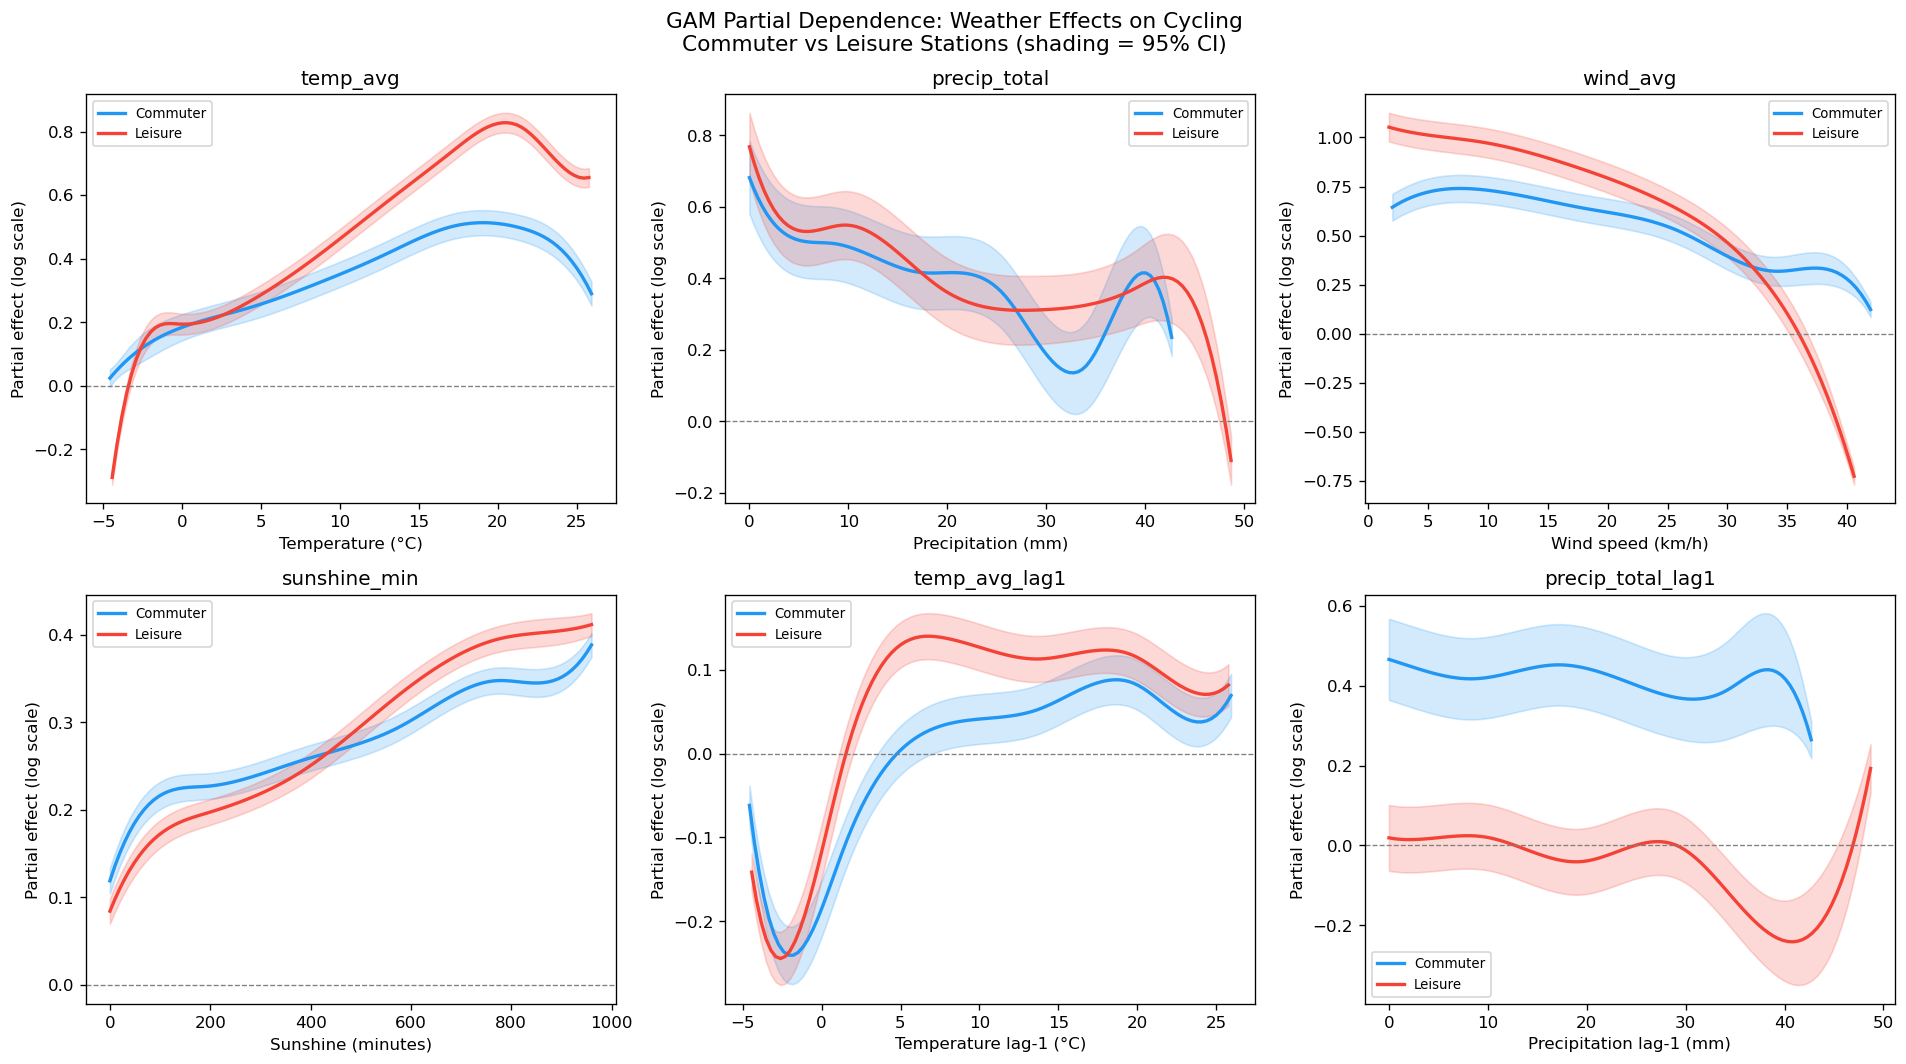

fig20 saved.


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

weather_terms = [
    (0, "temp_avg",           "Temperature (\u00b0C)",        axes[0, 0]),
    (1, "precip_total",       "Precipitation (mm)",           axes[0, 1]),
    (2, "wind_avg",           "Wind speed (km/h)",            axes[0, 2]),
    (3, "sunshine_min",       "Sunshine (minutes)",           axes[1, 0]),
    (5, "temp_avg_lag1",      "Temperature lag-1 (\u00b0C)",  axes[1, 1]),
    (6, "precip_total_lag1",  "Precipitation lag-1 (mm)",    axes[1, 2]),
]

for term_idx, feat_name, xlabel, ax in weather_terms:
    XX_c = gam_commuter.generate_X_grid(term=term_idx)
    XX_l = gam_leisure.generate_X_grid(term=term_idx)

    pdep_c, confi_c = gam_commuter.partial_dependence(
        term=term_idx, X=XX_c, width=0.95)
    pdep_l, confi_l = gam_leisure.partial_dependence(
        term=term_idx, X=XX_l, width=0.95)

    x_c = XX_c[:, term_idx]
    x_l = XX_l[:, term_idx]

    ax.plot(x_c, pdep_c, color=COLORS["commuter"], linewidth=2, label="Commuter")
    ax.fill_between(x_c, confi_c[:, 0], confi_c[:, 1],
                    alpha=0.2, color=COLORS["commuter"])
    ax.plot(x_l, pdep_l, color=COLORS["leisure"],  linewidth=2, label="Leisure")
    ax.fill_between(x_l, confi_l[:, 0], confi_l[:, 1],
                    alpha=0.2, color=COLORS["leisure"])

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Partial effect (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "GAM Partial Dependence: Weather Effects on Cycling\n"
    "Commuter vs Leisure Stations (shading = 95% CI)",
    fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "fig20_gam_partial_dependence.png", dpi=150)
plt.show()
print("fig20 saved.")

## 7. Weather-Normalized Cycling Index

Normalized cycling index saved.


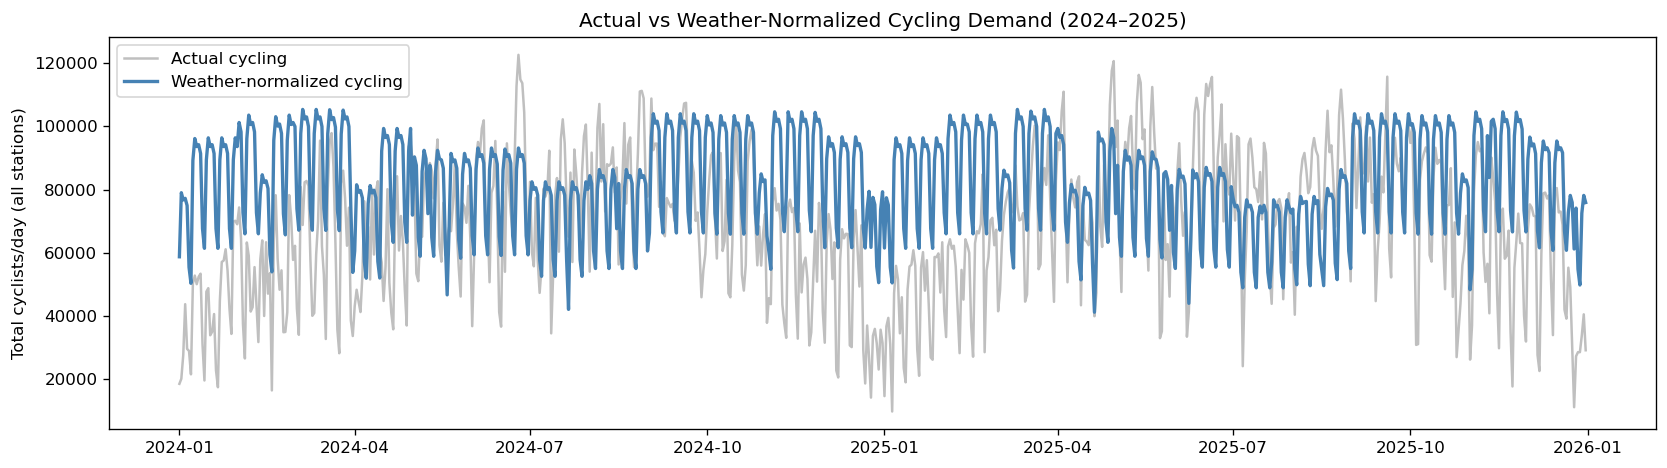

fig21 saved.


In [9]:
ref_weather = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
}

panel_norm = panel_good.copy()
panel_norm["date"]      = pd.to_datetime(panel_norm["date"])
panel_norm["site_idx"]  = le_site.transform(panel_norm["site ID"])
panel_norm["dow"]       = panel_norm["dayofweek"].astype(int)
panel_norm["month_int"] = panel_norm["month"].astype(int)
for col in ["is_weekend", "is_public_holiday",
            "is_school_holiday", "is_bad_weather"]:
    panel_norm[col] = panel_norm[col].astype(int)

X_norm       = panel_norm[ALL_FEATURES].copy()
for feat, val in ref_weather.items():
    X_norm[feat] = val

X_norm_clean       = X_norm.dropna()
panel_norm_clean   = panel_norm.loc[X_norm_clean.index].copy()
panel_norm_clean["normalized_count"] = gam_full.predict(X_norm_clean.values)

panel_norm_clean[["site ID", "naam", "date", "aantal",
                   "normalized_count", "site_type",
                   "day_type", "season"]].to_parquet(
    PROCESSED / "normalized_cycling.parquet", index=False
)
print("Normalized cycling index saved.")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values,
        alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index, daily_norm.values,
        color="steelblue", linewidth=2, label="Weather-normalized cycling")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2024\u20132025)")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "fig21_normalized_vs_actual.png", dpi=150)
plt.show()
print("fig21 saved.")

## 8. Weather Effect Magnitudes

In [10]:
def weather_effect(gam, ref_row, feature_idx, bad_val, ref_val):
    X_bad = ref_row.copy()
    X_ref = ref_row.copy()
    X_bad[feature_idx] = bad_val
    X_ref[feature_idx] = ref_val
    pred_bad = gam.predict(X_bad.reshape(1, -1))[0]
    pred_ref = gam.predict(X_ref.reshape(1, -1))[0]
    return (pred_bad - pred_ref) / pred_ref * 100

# Reference rows: column means from each model's training set
ref_row   = np.array([X_train[:, i].mean()   for i in range(X_train.shape[1])])
ref_row_c = np.array([X_train_c[:, i].mean() for i in range(X_train_c.shape[1])])
ref_row_l = np.array([X_train_l[:, i].mean() for i in range(X_train_l.shape[1])])

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    1, 20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     1,  2.0,   0.0),
    ("Cold day (0\u00b0C vs 15\u00b0C)",   0,  0.0,  15.0),
    ("Cool day (8\u00b0C vs 15\u00b0C)",   0,  8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", 2, 40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  3,  0.0, 300.0),
]

print("\n" + "=" * 55)
print("GAM WEATHER EFFECT SIZES")
print("=" * 55)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8}")
print("-" * 68)
for label, feat_idx, bad_val, ref_val in comparisons:
    eff_full = weather_effect(gam_full,     ref_row,   feat_idx, bad_val, ref_val)
    eff_c    = weather_effect(gam_commuter, ref_row_c, feat_idx, bad_val, ref_val)
    eff_l    = weather_effect(gam_leisure,  ref_row_l, feat_idx, bad_val, ref_val)
    print(f"{label:<35} | {eff_full:>6.1f}% | {eff_c:>8.1f}% | {eff_l:>7.1f}%")


GAM WEATHER EFFECT SIZES
Condition                           |    Full |  Commuter |  Leisure
--------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -30.1% |    -23.3% |   -33.4%
Light rain (2mm vs 0mm)             |  -12.2% |    -10.6% |   -14.2%
Cold day (0°C vs 15°C)              |  -29.9% |    -24.4% |   -37.0%
Cool day (8°C vs 15°C)              |  -18.3% |    -14.1% |   -23.6%
Strong wind (40 vs 10 km/h)         |  -61.3% |    -36.4% |   -79.4%
No sunshine (0 vs 300 min)          |  -11.9% |    -11.5% |   -12.6%


## 9. Save Models

In [11]:
models = {
    "gam_full"     : gam_full,
    "gam_commuter" : gam_commuter,
    "gam_leisure"  : gam_leisure,
    "le_site"      : le_site,
    "le_commuter"  : le_c,
    "le_leisure"   : le_l,
}
with open(PROCESSED / "gam_models.pkl", "wb") as fh:
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'gam_models.pkl'}")

Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/gam_models.pkl


## 10. Final Summary

In [12]:
heavy_rain_full = weather_effect(gam_full,    ref_row,   1, 20.0,  0.0)
cold_day_full   = weather_effect(gam_full,    ref_row,   0,  0.0, 15.0)
strong_wind_full= weather_effect(gam_full,    ref_row,   2, 40.0, 10.0)

print("=" * 52)
print("GAM MODELLING SUMMARY")
print("=" * 52)
print(f"Training period : 2024 ({len(y_train):,} observations)")
print(f"Test period     : 2025 ({len(y_test):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full GAM     : MAE={test_mae:.1f}, R\u00b2={r2_test:.3f}")
print(f"  Commuter GAM : MAE={mae_c:.1f}, R\u00b2={r2_c:.3f}")
print(f"  Leisure GAM  : MAE={mae_l:.1f}, R\u00b2={r2_l:.3f}")
print()
print("Key weather effects (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0\u00b0C)   : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")
print()
print("Outputs saved:")
print(f"  {PROCESSED / 'normalized_cycling.parquet'}")
print(f"  {PROCESSED / 'gam_models.pkl'}")
print(f"  {FIGS / 'fig20_gam_partial_dependence.png'}")
print(f"  {FIGS / 'fig21_normalized_vs_actual.png'}")
print("=" * 52)

GAM MODELLING SUMMARY
Training period : 2024 (48,098 observations)
Test period     : 2025 (47,830 observations)

Model performance (test set):
  Full GAM     : MAE=125.8, R²=0.878
  Commuter GAM : MAE=81.0, R²=0.899
  Leisure GAM  : MAE=145.5, R²=0.670

Key weather effects (full model):
  Heavy rain (20mm) : -30.1%
  Cold day (0°C)   : -29.9%
  Strong wind       : -61.3%

Outputs saved:
  /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/normalized_cycling.parquet
  /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/gam_models.pkl
  /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/outputs/figures/fig20_gam_partial_dependence.png
  /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/outputs/figures/fig21_normali